In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Cấu hình matplotlib hiển thị ảnh rõ ràng trong Notebook
plt.rcParams['figure.figsize'] = (10, 8)

### Bước 1: Đọc ảnh đã tăng tương phản từ Nhóm 1
Ta tiến hành quét thư mục `data/data_processing/tien_xu_ly` và lấy ra một ảnh đại diện để làm mẫu kiểm thử cho thuật toán Khử nhiễu và Tách biên.

Đang lấy ảnh mẫu từ Nhóm 1 để xử lý: carlong_0004.png


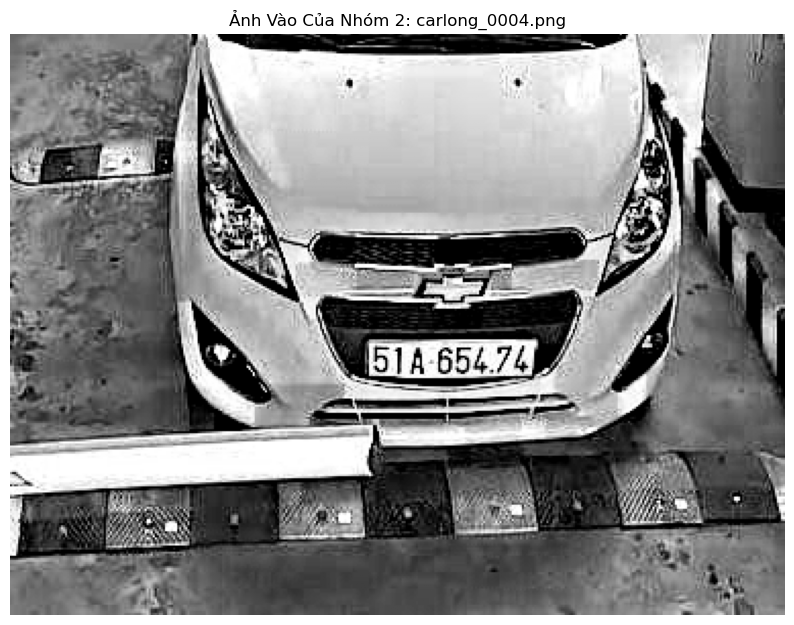

In [12]:
# Đường dẫn chứa ảnh đã được tăng tương phản từ Nhóm 1
input_dir = r"E:\Nhom_A\data\data_processing\tien_xu_ly"

# Quét lấy danh sách ảnh
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
processed_files = []
for ext in image_extensions:
    processed_files.extend(glob.glob(os.path.join(input_dir, ext)))

if len(processed_files) == 0:
    print(f"LỖI: Không tìm thấy ảnh nào trong thư mục: '{input_dir}'")
    print("Bạn hãy chạy Cell xử lý hàng loạt của Nhóm 1 trước để xuất ảnh ra nhé!")
else:
    # Lấy tấm ảnh đầu tiên làm mẫu test
    img_path = processed_files[0]
    print(f"Đang lấy ảnh mẫu từ Nhóm 1 để xử lý: {os.path.basename(img_path)}")
    
    # Đọc ảnh (Vì ảnh xuất ra từ Nhóm 1 đã là ảnh xám nên ta đọc ở chế độ Grayscale luôn)
    img_contrast = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Hiển thị ảnh đầu vào của Nhóm 2
    plt.imshow(img_contrast, cmap='gray')
    plt.title(f"Ảnh Vào Của Nhóm 2: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

### Bước 2: Giảm nhiễu bằng bộ lọc Gauss (Gaussian Blur)
Ảnh sau khi tăng tương phản có thể chứa các hạt nhiễu li ti bám trên bề mặt xe hoặc biển số. 
Ta áp dụng bộ lọc Gauss với kích thước mặt nạ (Kernel) là $5 \times 5$ để làm mượt ảnh, giúp thuật toán nhị phân hóa và tìm cạnh ở bước sau không bị bắt nhầm các hạt nhiễu này.

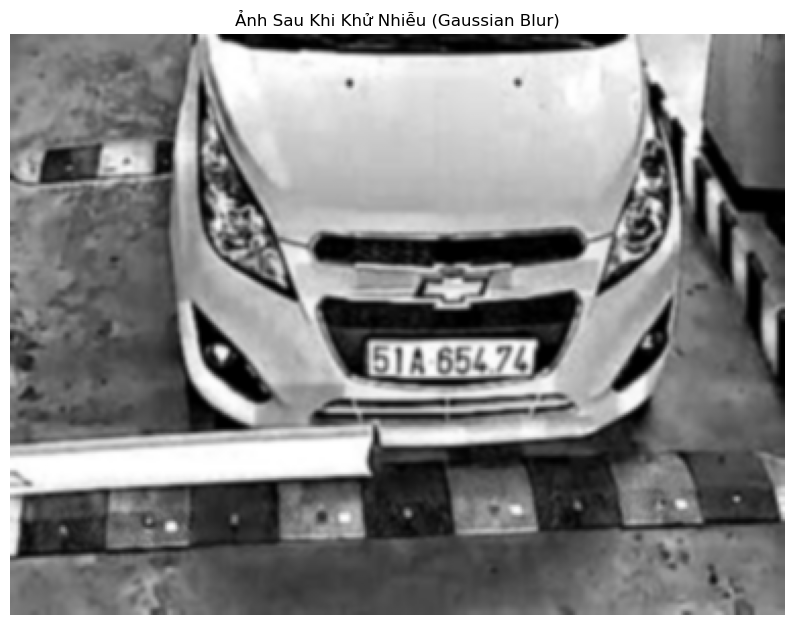

In [13]:
# Áp dụng Gaussian Blur, kernel kích thước (5, 5), sigmaX = 0 (tự động tính)
img_blur = cv2.GaussianBlur(img_contrast, (5, 5), 0)

# Hiển thị ảnh sau khi làm mịn
plt.imshow(img_blur, cmap='gray')
plt.title('Ảnh Sau Khi Khử Nhiễu (Gaussian Blur)')
plt.axis('off')
plt.show()

### Bước 3: Nhị phân hóa thích nghi cục bộ (Adaptive Thresholding)
Thay vì dùng một ngưỡng cố định cho toàn bộ bức ảnh (dễ bị mất nét ở vùng quá tối hoặc quá sáng), ta dùng phương pháp **Adaptive Thresholding**. 
Thuật toán sẽ tự tính toán ngưỡng nhị phân cho từng vùng nhỏ kích thước $19 \times 19$ pixel bằng toán tử Gauss (`ADAPTIVE_THRESH_GAUSSIAN_C`), giúp giữ lại trọn vẹn đường nét của biển số ngay cả khi xe bị chói đèn hay nằm dưới bóng râm.

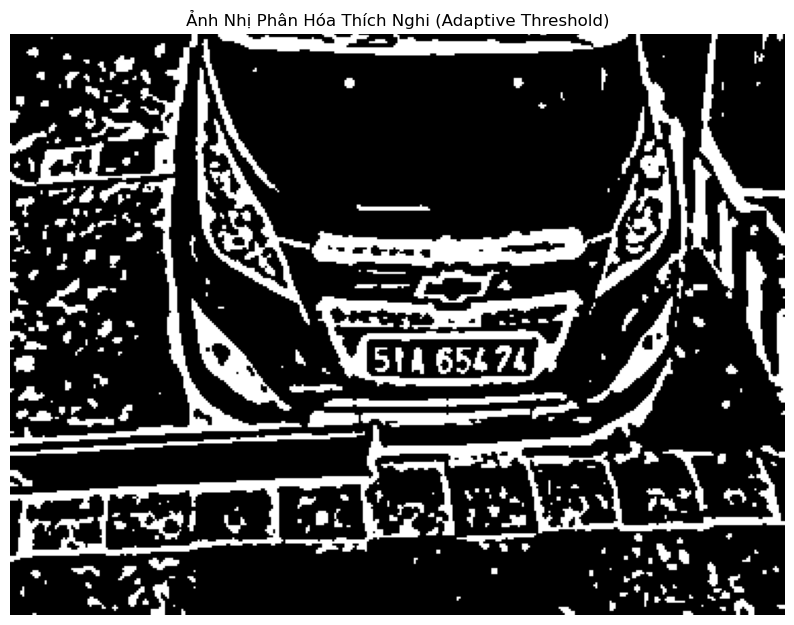

In [14]:
# Nhị phân hóa thích nghi: Ngưỡng cực đại 255, block_size = 19, hằng số C = 9 (thường dùng cho biển số)
img_thresh = cv2.adaptiveThreshold(
    img_blur, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 19, 9
)

# Hiển thị ảnh nhị phân (Đảo ngược: Nét biên màu trắng, nền màu đen để chuẩn hóa cho thuật toán tìm cạnh)
plt.imshow(img_thresh, cmap='gray')
plt.title('Ảnh Nhị Phân Hóa Thích Nghi (Adaptive Threshold)')
plt.axis('off')
plt.show()

### Bước 4: Phát hiện biên cạnh sắc nét bằng toán tử Canny
Từ ảnh nhị phân, ta đưa qua giải thuật **Canny Edge Detection** với hai ngưỡng lọc (Threshold1 = 100, Threshold2 = 200). 
Toán tử này sẽ giữ lại chính xác các đường biên bao quanh biển số xe và các kí tự bên trong, loại bỏ hầu hết các vùng mảng đặc trắng nhiễu không cần thiết.

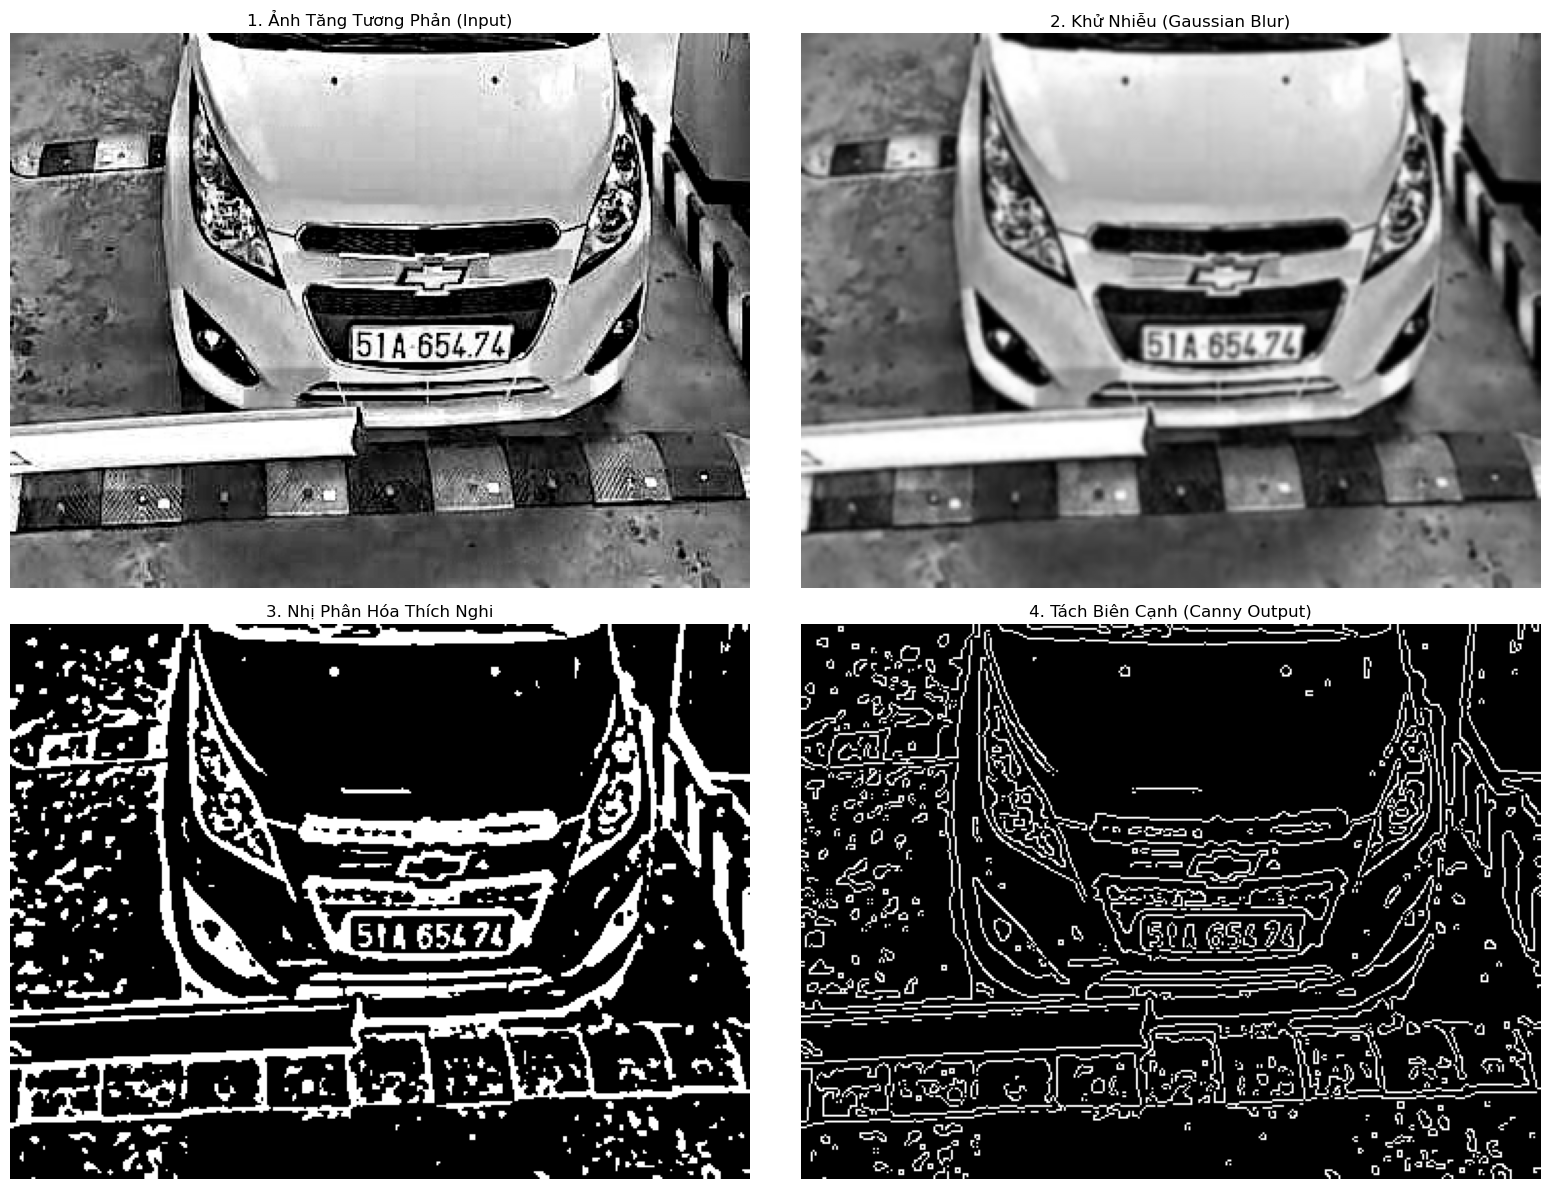

In [16]:
# Phát hiện cạnh bằng Canny
img_canny = cv2.Canny(img_thresh, 50, 150)

# Vẽ biểu đồ tổng hợp 4 bước biến đổi của Nhóm 2 để báo cáo
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].imshow(img_contrast, cmap='gray')
axs[0, 0].set_title('1. Ảnh Tăng Tương Phản (Input)')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_blur, cmap='gray')
axs[0, 1].set_title('2. Khử Nhiễu (Gaussian Blur)')
axs[0, 1].axis('off')

axs[1, 0].imshow(img_thresh, cmap='gray')
axs[1, 0].set_title('3. Nhị Phân Hóa Thích Nghi')
axs[1, 0].axis('off')

axs[1, 1].imshow(img_canny, cmap='gray')
axs[1, 1].set_title('4. Tách Biên Cạnh (Canny Output)')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Bước 5: Khử nhiễu và tách biên hàng loạt cho toàn bộ tập dữ liệu
Tiến hành quét toàn bộ ảnh trong thư mục đầu vào, áp dụng luồng xử lý trên và lưu kết quả cuối cùng (`img_canny`) vào thư mục `E:\Nhom_A\data\data_processing\khu_nhieu` để bàn giao cho Nhóm 3 thực hiện tìm khung biển số.

In [20]:
# Tạo thư mục đích cho Nhóm 2
output_dir_g2 = r"E:\Nhom_A\data\data_processing\khu_nhieu"
os.makedirs(output_dir_g2, exist_ok=True)

print(f"Bắt đầu chạy xử lý hàng loạt cho {len(processed_files)} ảnh...")

count = 0
for path in processed_files:
    # Đọc ảnh xám
    img_in = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_in is None:
        continue

    # 1. Gaussian Blur
    blur = cv2.GaussianBlur(img_in, (7, 7), 0)

    # 2. Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 19, 9
    )

    # 3. Canny Edge
    canny = cv2.Canny(thresh, 50, 150)

    # 4. Lưu ảnh
    file_name = os.path.basename(path)
    out_path = os.path.join(output_dir_g2, file_name)
    cv2.imwrite(out_path, canny)

    count += 1


print(f"Hoàn thành xuất sắc! Đã xử lý {count}/{len(processed_files)} ảnh.")
print(f"Ảnh biên cạnh Canny đã được lưu tại: '{output_dir_g2}'")

Bắt đầu chạy xử lý hàng loạt cho 2290 ảnh...
Hoàn thành xuất sắc! Đã xử lý 2290/2290 ảnh.
Ảnh biên cạnh Canny đã được lưu tại: 'E:\Nhom_A\data\data_processing\khu_nhieu'
